In [2]:
#%%
import cellpose.core
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['figure.dpi'] = 300
from cellpose import utils, io
from cellpose import models, io
import cellpose
import pandas as pd
import numpy as np
from skimage.io import imread
import scipy as sp
from cellpose import plot
from scipy.signal import savgol_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from skimage.segmentation import find_boundaries
from skimage.filters import threshold_local
import imageio


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, matthews_corrcoef

plt.rcParams["figure.figsize"] = (3,3)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline



In [3]:
cellpose.core.use_gpu()

True

In [4]:
data_directory="/n/boslfs02/LABS/murray_lab/Users/pnanda/DCS/Manuscript/eDCS031_TMRM_539/"
save_directory="/n/home01/pnandabbs/DCS/Manuscript/Figure2/Figure2A_TMRM_yPN585/"

In [5]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

model_type argument is not used in v4.0.1+. Ignoring this argument...


In [6]:
files=os.listdir(data_directory)

## 2% Glucose

model_type argument is not used in v4.0.1+. Ignoring this argument...


Arr mean 24.358071796544483
Rec mean 68.6152296159583
Arr mean 9.562483043459277
Rec mean 21.32794954131393


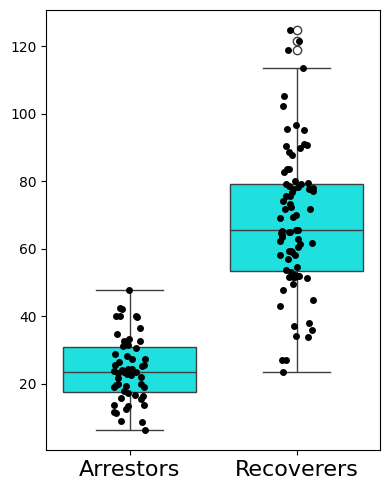

In [9]:
arr_vals=[]
rec_vals=[]

model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

for s in [1,5]:

    t=10

    img_stack=[]


    file_loc=data_directory+"yPN_w1Brightfield confocal_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack=imread(file_loc).astype('int16')

    file = np.stack(img_stack)

    num_cells=[]
    masks=[]

    masks_zero, flows, diams = model.eval(file[4], diameter=50)
    num_cells.append(masks_zero.max())
    masks.append(masks_zero)

    masks_arr=np.array(masks)

    labels=imread(save_directory+'Annotation/'+'Labels'+str(s)+'.tif')[10,:,:]

    img_stack_mcherry=[]
    img_stack_yfp=[]

    file_loc_mcherry=data_directory+"yPN_w3594 laser 50_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack_mcherry=imread(file_loc_mcherry).astype('int16')


    file_loc_gfp=data_directory+"yPN_w2488 laser 20_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack_gfp=imread(file_loc_gfp).astype('int16')

    tmrm=img_stack_mcherry[0:5].max(axis=0)

    gfp_stack=img_stack_gfp[0:5].max(axis=0)

    block_size = 31  # Must be odd number - adjust based on object size
    binary = gfp_stack > threshold_local(gfp_stack, block_size, offset=1)

    masks = masks_arr[0]

    # Get coordinates where labels exist (non-zero)
    label_coords = np.where(labels > 0)
    label_values = labels[label_coords]

    # For each label pixel, find which mask it belongs to
    mask_values_at_labels = masks[label_coords]

    # Create mapping
    df = pd.DataFrame({
        'mask_id': mask_values_at_labels,
        'label': label_values
    })

    # Remove background masks (mask_id == 0)
    df = df[df['mask_id'] > 0]

    # Get one label per mask (most common)
    df = df.groupby('mask_id')['label'].agg(lambda x: x.mode()[0]).reset_index()

    gfp_vals=[]
    for m in df['mask_id']:
        gfp_vals.append((tmrm[(masks==m)  & (binary==True)].mean()-tmrm[(masks==0)].mean()))

    df['Mean_GFP']=gfp_vals
    
    arr_vals.extend(df.loc[df['label']==1,'Mean_GFP'].tolist())
    rec_vals.extend(df.loc[df['label']==2,'Mean_GFP'].tolist())
    
full=arr_vals+rec_vals

rec_vals=np.array(rec_vals)[~np.isnan(rec_vals)]
arr_vals=np.array(arr_vals)[~np.isnan(arr_vals)]

print("Arr mean",np.nanmean(arr_vals))
print("Rec mean",np.nanmean(rec_vals))

print("Arr mean",np.nanstd(arr_vals))
print("Rec mean",np.nanstd(rec_vals))


plt.figure(figsize=(4,5))
sns.boxplot(data=[arr_vals,rec_vals],color='cyan')
sns.stripplot(data=[arr_vals,rec_vals],color='k')
plt.xticks([0,1],['Arrestors', 'Recoverers'],fontsize=16)
plt.tight_layout()

In [1]:
from scipy import stats
import numpy as np

# Fit distributions
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

# Mixture weight (e.g. by sample sizes)
w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

print(f'arr_vals: μ={mu_arr:.1f}, σ={std_arr:.1f}')
print(f'rec_vals: μ={mu_rec:.1f}, σ={std_rec:.1f}')
print(f'weights: w_arr={w_arr:.2f}, w_rec={w_rec:.2f}')

# Common x-axis covering both
x = np.linspace(min(arr_vals.min(), rec_vals.min()) - 20,
                max(arr_vals.max(), rec_vals.max()) + 20, 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.figure(figsize=(7,6))

# Hist of all cells if you want the combined distribution in data space
# sns.histplot(np.concatenate([arr_vals, rec_vals]),
#              bins=18, stat="density", alpha=0.3, color='tab:gray')

# Individual groups
sns.histplot(arr_vals, bins=6, stat="density", alpha=0.4, color='tab:blue')
sns.histplot(rec_vals, bins=12, stat="density", alpha=0.4, color='tab:orange')

# Individual fitted PDFs
plt.plot(x, pdf_arr, '--', linewidth=2, color='blue')
plt.plot(x, pdf_rec, '--', linewidth=2, color='orange')

# Mixture PDF
plt.plot(x, pdf_mix, '-', linewidth=2, color='k')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel(r'TMRM Fluorescence', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.legend(['Arrestors', 'Recoverers', 'Mixture'], fontsize=18)
plt.tight_layout()
# plt.savefig(save_directory+'mtsfGFP_distribution.jpg',dpi=1200)


NameError: name 'arr_vals' is not defined

F1: 0.9056603773584906
MCC: 0.7706284170463068


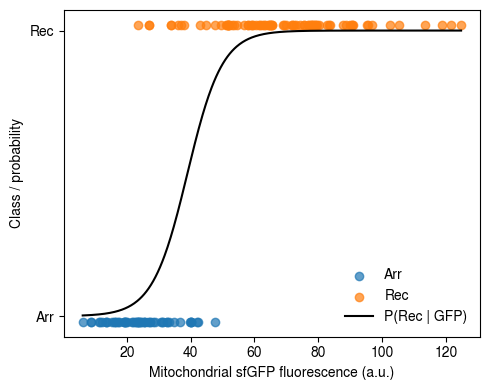

In [11]:
X = np.concatenate([arr_vals, rec_vals])[:, None]   # shape (n_samples, 1)
y = np.concatenate([
    np.zeros(arr_vals.shape[0], dtype=int),
    np.ones(rec_vals.shape[0], dtype=int)
])  # shape (n_samples,)

clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X, y)

y_pred = clf.predict(X)

f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)

print("F1:", f1)
print("MCC:", mcc)

x_grid = np.linspace(X.min(), X.max(), 500)[:, None]
p_grid = clf.predict_proba(x_grid)[:, 1]  # P(recovering | GFP)

plt.figure(figsize=(5, 4))

# real points, jittered vertically for visibility
plt.scatter(arr_vals, np.zeros_like(arr_vals) - 0.02,
            color='tab:blue', label='Arr', alpha=0.7)
plt.scatter(rec_vals, np.ones_like(rec_vals) + 0.02,
            color='tab:orange', label='Rec', alpha=0.7)

# logistic regression probability curve
plt.plot(x_grid.ravel(), p_grid, color='k', label='P(Rec | GFP)')

plt.yticks([0, 1], ['Arr', 'Rec'])
plt.xlabel(r"Mitochondrial sfGFP fluorescence (a.u.)")
plt.ylabel('Class / probability')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_directory + "tmrm2_logistic.png", dpi=300, bbox_inches="tight")


/tmp/ipykernel_174447/345223650.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_174447/345223650.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_174447/345223650.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


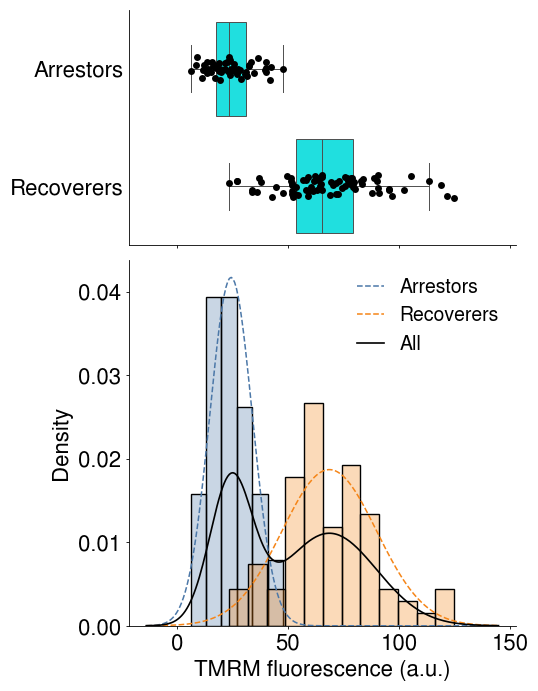

In [12]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Fit Gaussians ----------------
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

x = np.linspace(min(arr_vals.min(), rec_vals.min()) - 20,
                max(arr_vals.max(), rec_vals.max()) + 20, 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

# ---------------- Aesthetics ----------------
plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.6

arr_color = "#4C78A8"   # blue
rec_color = "#F58518"   # orange

# ---------------- Data frame ----------------
df_long = pd.DataFrame({
    "sfGFPmt": np.concatenate([arr_vals, rec_vals]),
    "State": (["Arrestors"] * len(arr_vals)) + (["Recoverers"] * len(rec_vals)),
})

bins_arr = np.histogram_bin_edges(arr_vals, bins=6)
bins_rec = np.histogram_bin_edges(rec_vals, bins=12)

# ---------------- Figure ----------------
fig = plt.figure(figsize=(5.0, 8.0), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[0.9, 1.4], hspace=0.05)

# Top: box + strip
ax_box = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, showfliers=False,
    palette=['cyan', 'cyan'],
    linewidth=0.7
)
sns.stripplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, color="k", size=5, alpha=1
)
ax_box.set_xlabel("")
ax_box.set_ylabel("")
ax_box.tick_params(axis="x", labelbottom=False, length=2, width=0.6)
ax_box.tick_params(axis="y", length=0, width=0.6)

# Bottom: hist + PDFs + mixture
ax_dist = fig.add_subplot(gs[1, 0], sharex=ax_box)

sns.histplot(
    arr_vals, bins=bins_arr, stat="density",
    color=arr_color, alpha=0.3, edgecolor="k", ax=ax_dist
)
sns.histplot(
    rec_vals, bins=bins_rec, stat="density",
    color=rec_color, alpha=0.3, edgecolor="k", ax=ax_dist
)

ax_dist.plot(x, pdf_arr, "--", linewidth=1.1, color=arr_color, label="Arrestors")
ax_dist.plot(x, pdf_rec, "--", linewidth=1.1, color=rec_color, label="Recoverers")
ax_dist.plot(x, pdf_mix, "-",  linewidth=1.2, color="k",        label="All")

ax_dist.set_xlabel(r"TMRM fluorescence (a.u.)")
ax_dist.set_ylabel("Density")
ax_dist.tick_params(length=2, width=0.6)
ax_dist.legend(frameon=False, fontsize=14, handlelength=1.4)

sns.despine(fig)
plt.tight_layout()

# High‑res, vector‑friendly save (adjust path as needed)
# fig.savefig(save_directory + "mtsfGFP_box_hist_mixture.pdf")
fig.savefig(save_directory + "tmrm_box_hist_mixture_d2.png", dpi=300, bbox_inches="tight")


## 0.05% Glucose

model_type argument is not used in v4.0.1+. Ignoring this argument...


Arr mean 59.682459624016055
Rec mean 125.56311962386398
Arr mean 16.660671171995304
Rec mean 38.21768793607674


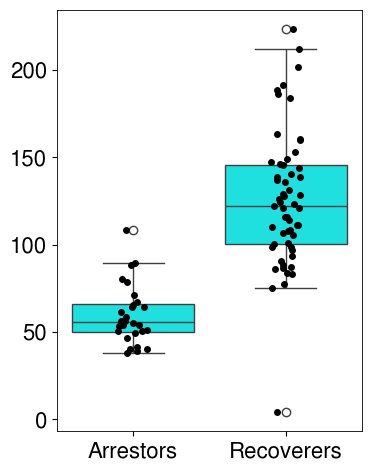

In [13]:
arr_vals=[]
rec_vals=[]

model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

for s in [11,13,15]:

    t=10

    img_stack=[]


    file_loc=data_directory+"yPN_w1Brightfield confocal_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack=imread(file_loc).astype('int16')

    file = np.stack(img_stack)

    num_cells=[]
    masks=[]

    masks_zero, flows, diams = model.eval(file[4], diameter=50)
    num_cells.append(masks_zero.max())
    masks.append(masks_zero)

    masks_arr=np.array(masks)

    labels=imread(save_directory+'Annotation/'+'Labels'+str(s)+'.tif')[10,:,:]

    img_stack_mcherry=[]
    img_stack_yfp=[]

    file_loc_mcherry=data_directory+"yPN_w3594 laser 50_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack_mcherry=imread(file_loc_mcherry).astype('int16')


    file_loc_gfp=data_directory+"yPN_w2488 laser 20_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack_gfp=imread(file_loc_gfp).astype('int16')

    tmrm=img_stack_mcherry[0:5].max(axis=0)

    gfp_stack=img_stack_gfp[0:5].max(axis=0)

    block_size = 11  # Must be odd number - adjust based on object size
    binary = gfp_stack > threshold_local(gfp_stack, block_size, offset=1)

    masks = masks_arr[0]

    # Get coordinates where labels exist (non-zero)
    label_coords = np.where(labels > 0)
    label_values = labels[label_coords]

    # For each label pixel, find which mask it belongs to
    mask_values_at_labels = masks[label_coords]

    # Create mapping
    df = pd.DataFrame({
        'mask_id': mask_values_at_labels,
        'label': label_values
    })

    # Remove background masks (mask_id == 0)
    df = df[df['mask_id'] > 0]

    # Get one label per mask (most common)
    df = df.groupby('mask_id')['label'].agg(lambda x: x.mode()[0]).reset_index()

    gfp_vals=[]
    for m in df['mask_id']:
        gfp_vals.append((tmrm[(masks==m)  & (binary==True)].mean()-tmrm[(masks==0)].mean()))

    df['Mean_GFP']=gfp_vals
    
    arr_vals.extend(df.loc[df['label']==1,'Mean_GFP'].tolist())
    rec_vals.extend(df.loc[df['label']==2,'Mean_GFP'].tolist())
    
full=arr_vals+rec_vals

rec_vals=np.array(rec_vals)[~np.isnan(rec_vals)]
arr_vals=np.array(arr_vals)[~np.isnan(arr_vals)]

print("Arr mean",np.nanmean(arr_vals))
print("Rec mean",np.nanmean(rec_vals))

print("Arr mean",np.nanstd(arr_vals))
print("Rec mean",np.nanstd(rec_vals))

plt.figure(figsize=(4,5))
sns.boxplot(data=[arr_vals,rec_vals],color='cyan')
sns.stripplot(data=[arr_vals,rec_vals],color='k')
plt.xticks([0,1],['Arrestors', 'Recoverers'],fontsize=16)
plt.tight_layout()

arr_vals: μ=59.7, σ=16.7
rec_vals: μ=125.6, σ=38.2
weights: w_arr=0.33, w_rec=0.67


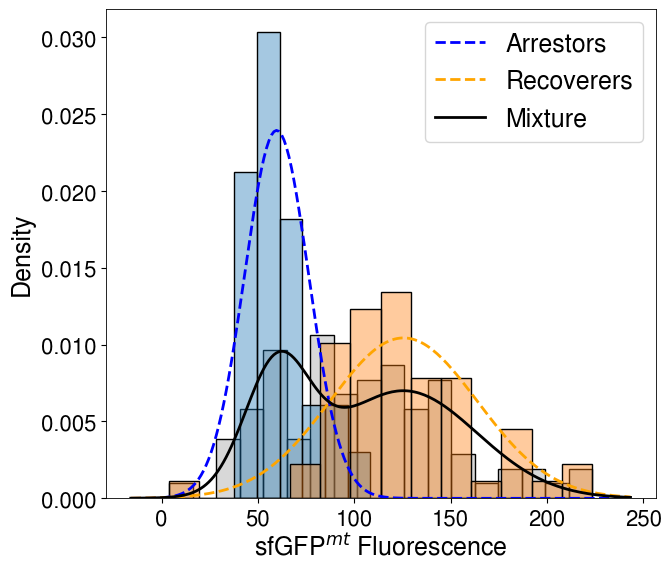

In [14]:
from scipy import stats
import numpy as np

# Fit distributions
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

# Mixture weight (e.g. by sample sizes)
w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

print(f'arr_vals: μ={mu_arr:.1f}, σ={std_arr:.1f}')
print(f'rec_vals: μ={mu_rec:.1f}, σ={std_rec:.1f}')
print(f'weights: w_arr={w_arr:.2f}, w_rec={w_rec:.2f}')

# Common x-axis covering both
x = np.linspace(min(arr_vals.min(), rec_vals.min()) - 20,
                max(arr_vals.max(), rec_vals.max()) + 20, 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.figure(figsize=(7,6))

# Hist of all cells if you want the combined distribution in data space
sns.histplot(np.concatenate([arr_vals, rec_vals]),
             bins=18, stat="density", alpha=0.3, color='tab:gray')

# Individual groups
sns.histplot(arr_vals, bins=6, stat="density", alpha=0.4, color='tab:blue')
sns.histplot(rec_vals, bins=14, stat="density", alpha=0.4, color='tab:orange')

# Individual fitted PDFs
plt.plot(x, pdf_arr, '--', linewidth=2, color='blue')
plt.plot(x, pdf_rec, '--', linewidth=2, color='orange')

# Mixture PDF
plt.plot(x, pdf_mix, '-', linewidth=2, color='k')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel(r'sfGFP$^{mt}$ Fluorescence', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.legend(['Arrestors', 'Recoverers', 'Mixture'], fontsize=18)
plt.tight_layout()
# plt.savefig(save_directory+'mtsfGFP_distribution.jpg',dpi=1200)


/tmp/ipykernel_174447/2310678181.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_174447/2310678181.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_174447/2310678181.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


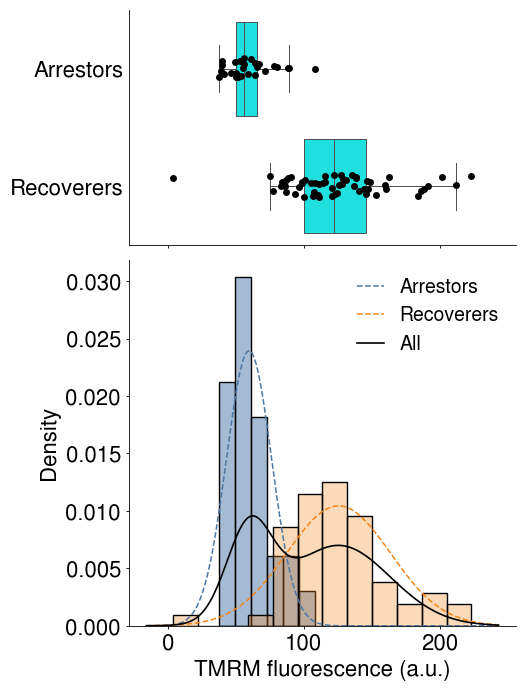

In [15]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Fit Gaussians ----------------
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

x = np.linspace(min(arr_vals.min(), rec_vals.min()) - 20,
                max(arr_vals.max(), rec_vals.max()) + 20, 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

# ---------------- Aesthetics ----------------
plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.6

arr_color = "#4C78A8"   # blue
rec_color = "#F58518"   # orange

# ---------------- Data frame ----------------
df_long = pd.DataFrame({
    "sfGFPmt": np.concatenate([arr_vals, rec_vals]),
    "State": (["Arrestors"] * len(arr_vals)) + (["Recoverers"] * len(rec_vals)),
})

bins_arr = np.histogram_bin_edges(arr_vals, bins=6)
bins_rec = np.histogram_bin_edges(rec_vals, bins=12)

# ---------------- Figure ----------------
fig = plt.figure(figsize=(5.0, 8.0), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[0.9, 1.4], hspace=0.05)

# Top: box + strip
ax_box = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, showfliers=False,
    palette=['cyan', 'cyan'],
    linewidth=0.7
)
sns.stripplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, color="k", size=5, alpha=1
)
ax_box.set_xlabel("")
ax_box.set_ylabel("")
ax_box.tick_params(axis="x", labelbottom=False, length=2, width=0.6)
ax_box.tick_params(axis="y", length=0, width=0.6)

# Bottom: hist + PDFs + mixture
ax_dist = fig.add_subplot(gs[1, 0], sharex=ax_box)

sns.histplot(
    arr_vals, bins=bins_arr, stat="density",
    color=arr_color, alpha=0.5, edgecolor="k", ax=ax_dist
)
sns.histplot(
    rec_vals, bins=bins_rec, stat="density",
    color=rec_color, alpha=0.3, edgecolor="k", ax=ax_dist
)

ax_dist.plot(x, pdf_arr, "--", linewidth=1.1, color=arr_color, label="Arrestors")
ax_dist.plot(x, pdf_rec, "--", linewidth=1.1, color=rec_color, label="Recoverers")
ax_dist.plot(x, pdf_mix, "-",  linewidth=1.2, color="k",        label="All")

ax_dist.set_xlabel(r"TMRM fluorescence (a.u.)")
ax_dist.set_ylabel("Density")
ax_dist.tick_params(length=2, width=0.6)
ax_dist.legend(frameon=False, fontsize=14, handlelength=1.4)

sns.despine(fig)
plt.tight_layout()

# High‑res, vector‑friendly save (adjust path as needed)
# fig.savefig(save_directory + "mtsfGFP_box_hist_mixture.pdf")
fig.savefig(save_directory + "tmrm_box_hist_mixture_d005.png", dpi=300, bbox_inches="tight")


F1: 0.9391304347826087
MCC: 0.8121807678999131


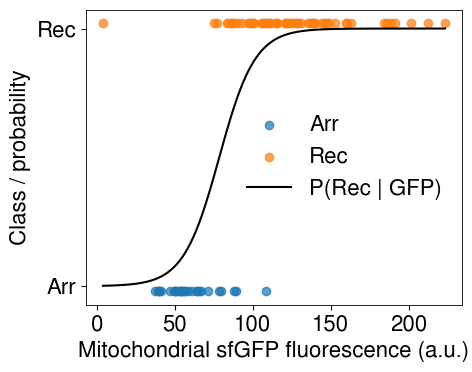

In [16]:
X = np.concatenate([arr_vals, rec_vals])[:, None]   # shape (n_samples, 1)
y = np.concatenate([
    np.zeros(arr_vals.shape[0], dtype=int),
    np.ones(rec_vals.shape[0], dtype=int)
])  # shape (n_samples,)

clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X, y)

y_pred = clf.predict(X)

f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)

print("F1:", f1)
print("MCC:", mcc)

x_grid = np.linspace(X.min(), X.max(), 500)[:, None]
p_grid = clf.predict_proba(x_grid)[:, 1]  # P(recovering | GFP)

plt.figure(figsize=(5, 4))

# real points, jittered vertically for visibility
plt.scatter(arr_vals, np.zeros_like(arr_vals) - 0.02,
            color='tab:blue', label='Arr', alpha=0.7)
plt.scatter(rec_vals, np.ones_like(rec_vals) + 0.02,
            color='tab:orange', label='Rec', alpha=0.7)

# logistic regression probability curve
plt.plot(x_grid.ravel(), p_grid, color='k', label='P(Rec | GFP)')

plt.yticks([0, 1], ['Arr', 'Rec'])
plt.xlabel(r"Mitochondrial sfGFP fluorescence (a.u.)")
plt.ylabel('Class / probability')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_directory + "tmrm005_logistic.png", dpi=300, bbox_inches="tight")


/tmp/ipykernel_174447/1337359706.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_174447/1337359706.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_174447/1337359706.py:85: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

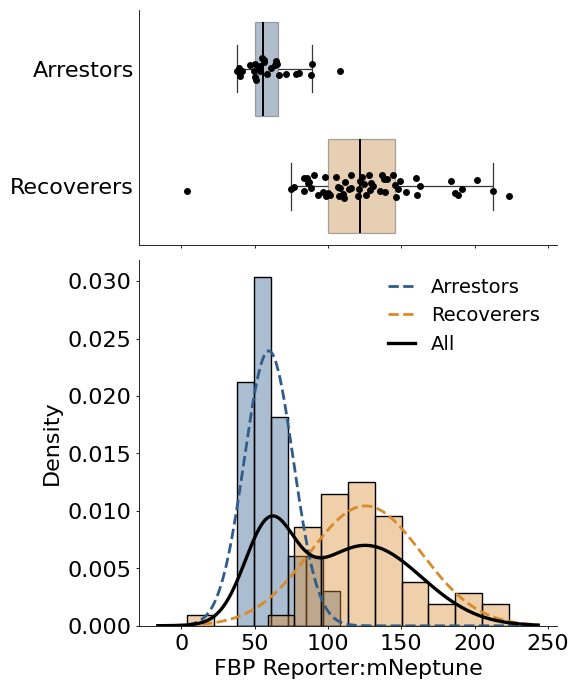

In [18]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Fit Gaussians ----------------
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

x = np.linspace(min(arr_vals.min(), rec_vals.min()) - 20,
                max(arr_vals.max(), rec_vals.max()) + 20, 200)
pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

# ---------------- Aesthetics ----------------
plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.6

arr_color  = "#2F5C8A"   # denim
rec_color  = "#D98A2B"   # amber
fill_alpha = 0.4         # one alpha for every fill: both groups, box + histogram

# ---------------- Data frame ----------------
df_long = pd.DataFrame({
    "sfGFPmt": np.concatenate([arr_vals, rec_vals]),
    "State": (["Arrestors"] * len(arr_vals)) + (["Recoverers"] * len(rec_vals)),
})

bins_arr = np.histogram_bin_edges(arr_vals, bins=6)
bins_rec = np.histogram_bin_edges(rec_vals, bins=12)

# ---------------- Figure ----------------
fig = plt.figure(figsize=(5.4, 8.0), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[0.9, 1.4], hspace=0.05)

# Top: box + strip
ax_box = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, showfliers=False,
    palette=[arr_color, rec_color],
    linewidth=0.9,
    boxprops=dict(alpha=fill_alpha),
    medianprops=dict(color="k", linewidth=1.4),
)
sns.stripplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, color="k", size=5, alpha=1
)
ax_box.set_xlabel("")
ax_box.set_ylabel("")
ax_box.tick_params(axis="x", labelbottom=False, length=2, width=0.6)
ax_box.tick_params(axis="y", length=0, width=0.6)

# Bottom: hist + PDFs + mixture
ax_dist = fig.add_subplot(gs[1, 0], sharex=ax_box)

sns.histplot(
    arr_vals, bins=bins_arr, stat="density",
    color=arr_color, alpha=fill_alpha, edgecolor="k", ax=ax_dist
)
sns.histplot(
    rec_vals, bins=bins_rec, stat="density",
    color=rec_color, alpha=fill_alpha, edgecolor="k", ax=ax_dist
)

ax_dist.plot(x, pdf_arr, "--", linewidth=2, color=arr_color, label="Arrestors")
ax_dist.plot(x, pdf_rec, "--", linewidth=2, color=rec_color, label="Recoverers")
ax_dist.plot(x, pdf_mix, "-",  linewidth=2.4, color="k",        label="All")

ax_dist.set_xlabel(r"FBP Reporter:mNeptune")
ax_dist.set_ylabel("Density")
ax_dist.tick_params(length=2, width=0.6)
ax_dist.legend(frameon=False, fontsize=14, handlelength=1.4, loc='best')

sns.despine(fig)
plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it

# High-res, vector-friendly save (adjust path as needed)
# fig.savefig(save_directory + "mtsfGFP_box_hist_mixture.pdf")
fig.savefig("Figure2_TMRM_heterogeneityD005.svg", format="svg",dpi=1200)